# Предобработка данных
## Обработка пропусков · Кодирование категорий · Масштабирование

---

### Описание датасета

В качестве датасета используется **Titanic** — классический набор данных о пассажирах парохода «Титаник» (апрель 1912 г.). Он широко применяется в задачах бинарной классификации: предсказание выживания пассажира.

| Признак | Тип | Описание | Пропуски |
|---|---|---|---|
| `PassengerId` | int | Уникальный ID | нет |
| `Survived` | int | Выжил (1) / погиб (0) — целевая переменная | нет |
| `Pclass` | int | Класс каюты (1, 2, 3) | нет |
| `Sex` | str | Пол | нет |
| `Age` | float | Возраст | **~20%** |
| `SibSp` | int | Кол-во братьев/сестёр/супругов на борту | нет |
| `Parch` | int | Кол-во родителей/детей на борту | нет |
| `Fare` | float | Стоимость билета | **~0.2%** |
| `Cabin` | str | Номер каюты | **~77%** |
| `Embarked` | str | Порт посадки (S/C/Q) | **~0.1%** |

**Датасет идеально подходит для демонстрации предобработки:** содержит пропуски разного характера, смешанные типы данных и категориальные признаки.

In [ ]:
# ─────────────────────────────────────────
#  Импорт библиотек
# ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    LabelEncoder, OrdinalEncoder,
    OneHotEncoder,
    StandardScaler, MinMaxScaler, RobustScaler
)
from sklearn.impute import SimpleImputer, KNNImputer

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.3f}'.format)

# Загрузка датасета
df_raw = pd.read_csv('titanic_like.csv')
df = df_raw.copy()

print(f'Форма датасета: {df.shape}')
df.head()

Датасет успешно загружен!


---

## 1. Обработка пропусков в данных

### 1.1 Анализ пропущенных значений

In [ ]:
# Сводная таблица пропусков
missing = pd.DataFrame({
    'Количество пропусков': df.isnull().sum(),
    'Доля пропусков (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Количество пропусков'] > 0].sort_values('Доля пропусков (%)', ascending=False)
print('Признаки с пропусками:')
print(missing)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap пропусков
sns.heatmap(df.isnull(), cbar=False, yticklabels=False,
            cmap=['#eef2f7', '#E05C5C'], ax=axes[0])
axes[0].set_title('Карта пропущенных значений\n(красный = пропуск)', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)

# Bar chart долей пропусков
colors = ['#E05C5C' if v > 30 else '#F0A050' if v > 5 else '#5B9BD5'
          for v in missing['Доля пропусков (%)']]
axes[1].barh(missing.index, missing['Доля пропусков (%)'], color=colors, edgecolor='white')
axes[1].set_title('Доля пропусков по признакам', fontsize=12)
axes[1].set_xlabel('Доля пропусков (%)')
for i, v in enumerate(missing['Доля пропусков (%)']):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)
axes[1].set_xlim(0, 95)

plt.tight_layout()
plt.savefig('missing_analysis.png', bbox_inches='tight')
plt.show()

Признаки с пропусками:
              Количество пропусков  Доля пропусков (%)
Cabin                          687               77.11
Age                            187               20.99
Fare                             2                0.22
Embarked                         1                0.11


### 1.2 Стратегии заполнения пропусков

Выбор стратегии зависит от:
- **доли пропусков** — если > 50–70%, признак часто удаляют
- **типа признака** — числовой или категориальный
- **механизма пропусков** — MCAR / MAR / MNAR

| Признак | Доля | Стратегия |
|---|---|---|
| `Cabin` | ~77% | Удаление признака |
| `Age` | ~20% | Медиана / KNN-импутация |
| `Fare` | ~0.2% | Медиана |
| `Embarked` | ~0.1% | Мода (наиболее частое значение) |

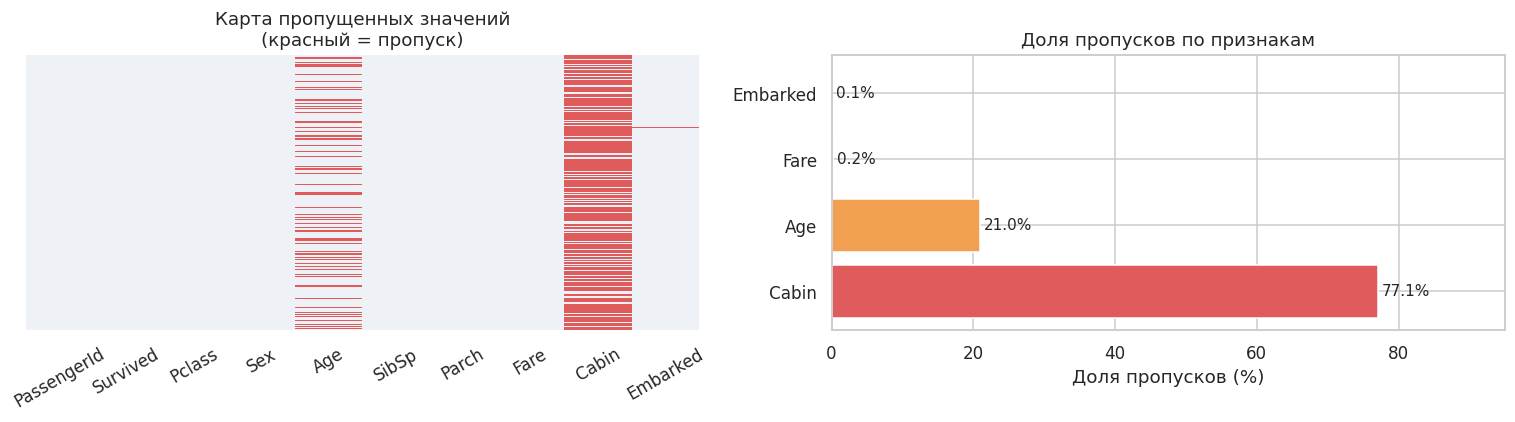

In [ ]:
df_imp = df.copy()

# ── 1) Удаление Cabin (слишком много пропусков) ──────────────────
cabin_pct = df_imp['Cabin'].isnull().mean() * 100
print(f'Cabin: {cabin_pct:.1f}% пропусков → удаляем признак')
df_imp.drop(columns=['Cabin'], inplace=True)

# ── 2) Fare: числовой, 2 пропуска → медиана ──────────────────────
fare_median = df_imp['Fare'].median()
df_imp['Fare'].fillna(fare_median, inplace=True)
print(f'Fare: заполнено медианой = {fare_median:.2f}')

# ── 3) Embarked: категориальный, 1 пропуск → мода ────────────────
emb_mode = df_imp['Embarked'].mode()[0]
df_imp['Embarked'].fillna(emb_mode, inplace=True)
print(f'Embarked: заполнено модой = "{emb_mode}"')

# ── 4) Age: ~20% пропусков, сравним два метода ───────────────────

# Метод А: SimpleImputer — медиана
df_median = df_imp.copy()
age_median = df_median['Age'].median()
df_median['Age'].fillna(age_median, inplace=True)

# Метод Б: KNNImputer (k=5) по числовым признакам
df_knn = df_imp.copy()
num_cols_knn = ['Age', 'Fare', 'Pclass', 'SibSp', 'Parch']
knn_imp = KNNImputer(n_neighbors=5)
df_knn[num_cols_knn] = knn_imp.fit_transform(df_knn[num_cols_knn])

print(f'\nAge — медиана оригинала: {age_median:.2f}')
print(f'Age — среднее после медианы:    {df_median["Age"].mean():.2f}')
print(f'Age — среднее после KNN:        {df_knn["Age"].mean():.2f}')

print(f'\nПропусков в df после импутации: {df_median.isnull().sum().sum()}')

In [ ]:
# Сравнение распределения Age до и после импутации
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

original_age = df['Age'].dropna().astype(float)
median_age = df_median['Age'].astype(float)
knn_age = df_knn['Age'].astype(float)

for ax, data, title, color in zip(
    axes,
    [original_age, median_age, knn_age],
    ['Оригинал (без пропусков)', 'После заполнения медианой', 'После KNN-импутации'],
    ['#5B9BD5', '#F0A050', '#55A868']
):
    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Среднее: {data.mean():.1f}')
    ax.axvline(data.median(), color='black', linestyle=':', linewidth=1.5, label=f'Медиана: {data.median():.1f}')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Age')
    ax.set_ylabel('Частота')
    ax.legend(fontsize=9)

plt.suptitle('Распределение Age: сравнение методов импутации', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('imputation_comparison.png', bbox_inches='tight')
plt.show()

# Используем KNN как финальный вариант
df_clean = df_knn.copy()
print('\n✓ Финальный датасет сформирован: df_clean')
print(f'  Форма: {df_clean.shape}')
print(f'  Пропусков: {df_clean.isnull().sum().sum()}')

Cabin: 77.1% пропусков → удаляем признак
Fare: заполнено медианой = 27.84
Embarked: заполнено модой = "S"

Age — медиана оригинала: 29.80
Age — среднее после медианы:    29.57
Age — среднее после KNN:        29.43

Пропусков в df после импутации: 0


---

## 2. Кодирование категориальных признаков

### 2.1 Анализ категориальных признаков

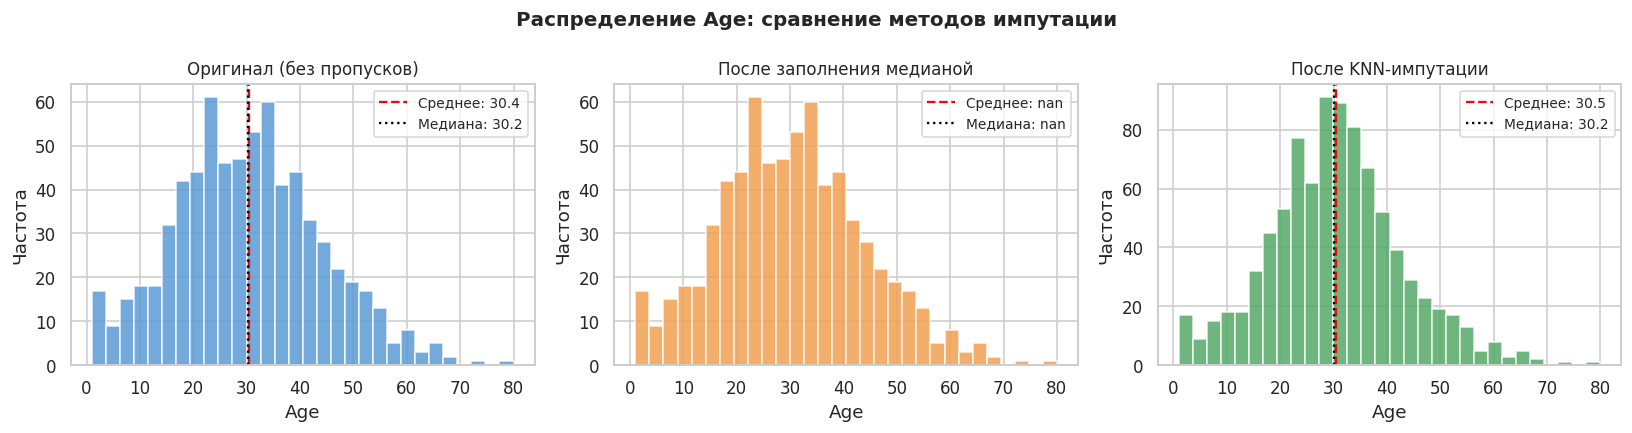

In [ ]:
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print('Категориальные признаки:', cat_cols)
print()
for col in cat_cols:
    vc = df_clean[col].value_counts()
    print(f'{col} — уникальных значений: {df_clean[col].nunique()}')
    print(vc.to_string())
    print()

In [ ]:
fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))
if len(cat_cols) == 1:
    axes = [axes]

colors_list = ['#5B9BD5', '#55A868', '#E05C5C']
for ax, col, clr in zip(axes, cat_cols, colors_list):
    vc = df_clean[col].value_counts()
    ax.bar(vc.index, vc.values, color=clr, edgecolor='white', alpha=0.85)
    ax.set_title(f'Распределение: {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Количество')
    for i, v in enumerate(vc.values):
        ax.text(i, v + 5, str(v), ha='center', fontsize=10)

plt.suptitle('Категориальные признаки', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_dist.png', bbox_inches='tight')
plt.show()

Категориальные признаки: ['Sex', 'Embarked']

Sex — уникальных значений: 2
male      580
female    311

Embarked — уникальных значений: 3
S    643
C    169
Q     79


### 2.2 Label Encoding (бинарный признак Sex)

**Label Encoding** — замена категорий на целые числа. Подходит для **бинарных** или **порядковых** признаков. Не рекомендуется для номинальных с 3+ классами — модель может воспринять числа как упорядоченные.

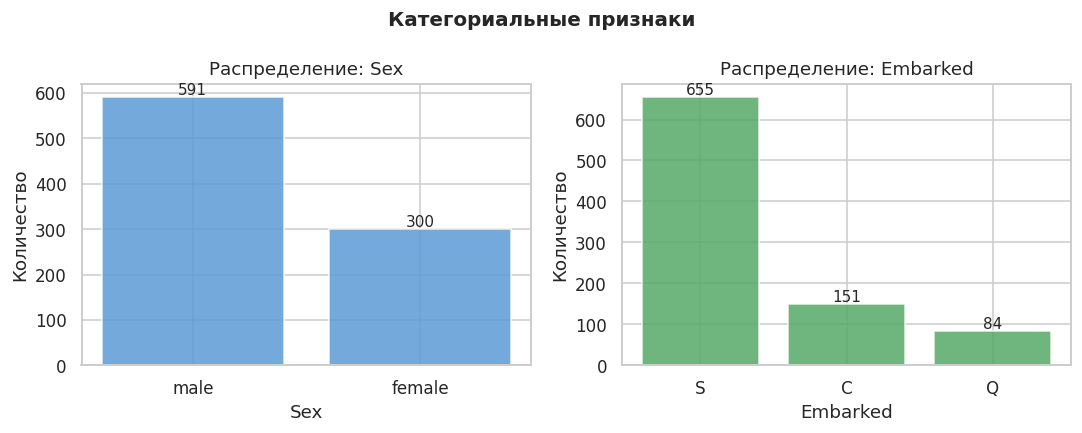

In [ ]:
df_encoded = df_clean.copy()

# Label Encoding для Sex (бинарный: male/female)
le = LabelEncoder()
df_encoded['Sex_LE'] = le.fit_transform(df_encoded['Sex'])

print('Label Encoding — Sex:')
print('  Классы:', list(le.classes_))
print('  Кодировка:', dict(zip(le.classes_, le.transform(le.classes_))))
print()
print(df_encoded[['Sex', 'Sex_LE']].drop_duplicates().sort_values('Sex_LE'))

### 2.3 Ordinal Encoding (признак Pclass)

**Ordinal Encoding** — задаём явный порядок категорий. Pclass — класс каюты (1 = первый, самый дорогой; 3 = третий, эконом). Порядок имеет смысл → можно кодировать как упорядоченный.

In [ ]:
# Pclass уже числовой (1, 2, 3), но продемонстрируем OrdinalEncoder
# Сначала создадим строковую версию
df_encoded['Pclass_str'] = df_encoded['Pclass'].map({1: 'First', 2: 'Second', 3: 'Third'})

oe = OrdinalEncoder(categories=[['Third', 'Second', 'First']])
df_encoded['Pclass_OE'] = oe.fit_transform(df_encoded[['Pclass_str']]).astype(int)

print('Ordinal Encoding — Pclass:')
print('  Порядок: Third=0, Second=1, First=2')
print()
print(df_encoded[['Pclass_str', 'Pclass_OE']].drop_duplicates().sort_values('Pclass_OE'))

Label Encoding — Sex:
  Классы: ['female', 'male']
  Кодировка: {'female': 0, 'male': 1}

      Sex  Sex_LE
0  female       0
1    male       1


### 2.4 One-Hot Encoding (признак Embarked)

**One-Hot Encoding (OHE)** — создаёт бинарный столбец для каждой категории. Применяется для **номинальных** признаков без порядка. При k классах создаёт k (или k-1 с `drop='first'`) новых признаков.

In [ ]:
# pandas get_dummies — удобный способ OHE
embarked_dummies = pd.get_dummies(df_encoded['Embarked'], prefix='Embarked', dtype=int)
print('pd.get_dummies для Embarked:')
print(embarked_dummies.head(8))
print()

# Также sklearn OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' избегает мультиколлинеарности
ohe_result = ohe.fit_transform(df_encoded[['Embarked']])
ohe_cols = [f'Embarked_{c}' for c in ohe.categories_[0][1:]]
df_ohe = pd.DataFrame(ohe_result, columns=ohe_cols, dtype=int)

print('sklearn OneHotEncoder (drop=first) для Embarked:')
print(df_ohe.head(8))

# Добавляем OHE-столбцы в датасет
df_encoded = pd.concat([df_encoded, embarked_dummies], axis=1)
print('\nИтоговые столбцы после OHE:', list(embarked_dummies.columns))

Ordinal Encoding — Pclass:
  Порядок: Third=0, Second=1, First=2

  Pclass_str  Pclass_OE
0      Third          0
1     Second          1
2      First          2


In [ ]:
# Итоговая сводка кодирования
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Label Encoding
axes[0].bar(['female\n→ 0', 'male\n→ 1'],
            df_encoded['Sex'].value_counts().sort_index().values,
            color=['#E991A5', '#5B9BD5'], edgecolor='white')
axes[0].set_title('Label Encoding: Sex', fontsize=12)
axes[0].set_ylabel('Количество')

# Ordinal Encoding
axes[1].bar(['Third\n→ 0', 'Second\n→ 1', 'First\n→ 2'],
            df_encoded['Pclass_str'].value_counts()[['Third','Second','First']].values,
            color=['#E05C5C', '#F0A050', '#55A868'], edgecolor='white')
axes[1].set_title('Ordinal Encoding: Pclass', fontsize=12)
axes[1].set_ylabel('Количество')

# One-Hot
emb_cols = ['Embarked_C', 'Embarked_Q', 'Embarked_S']
emb_sums = embarked_dummies.sum()
axes[2].bar(emb_sums.index, emb_sums.values,
            color=['#5B9BD5', '#55A868', '#F0A050'], edgecolor='white')
axes[2].set_title('One-Hot Encoding: Embarked', fontsize=12)
axes[2].set_ylabel('Количество единиц')

plt.suptitle('Результаты кодирования категориальных признаков', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('encoding_results.png', bbox_inches='tight')
plt.show()

print('\nСравнение методов кодирования:')
print(f'{"Метод":<22} {"Признак":<12} {"Новых столбцов"}')
print('-' * 50)
print(f'{"Label Encoding":<22} {"Sex":<12} 1 (заменяет оригинал)')
print(f'{"Ordinal Encoding":<22} {"Pclass":<12} 1 (заменяет оригинал)')
print(f'{"One-Hot (все)":<22} {"Embarked":<12} 3 (новые бинарные)')
print(f'{"One-Hot (drop=first)":<22} {"Embarked":<12} 2 (без мультиколл.)')

pd.get_dummies для Embarked:
   Embarked_C  Embarked_Q  Embarked_S
0           0           0           1
1           0           1           0
2           0           0           1
3           1           0           0
4           0           0           1
5           0           0           1
6           0           0           1
7           0           0           1

sklearn OneHotEncoder (drop=first) для Embarked:
   Embarked_Q  Embarked_S
0           0           1
1           1           0
2           0           1
3           0           0
4           0           1
5           0           1
6           0           1
7           0           1

Итоговые столбцы после OHE: ['Embarked_C', 'Embarked_Q', 'Embarked_S']

---

## 3. Масштабирование данных

### 3.1 Зачем масштабировать?

Многие алгоритмы (KNN, SVM, градиентный спуск, PCA) чувствительны к масштабу признаков. Признаки с большими значениями (например, `Fare` ~ 0–512) будут доминировать над признаками с малыми (например, `Parch` ~ 0–3).

### 3.2 Анализ масштаба признаков до нормализации

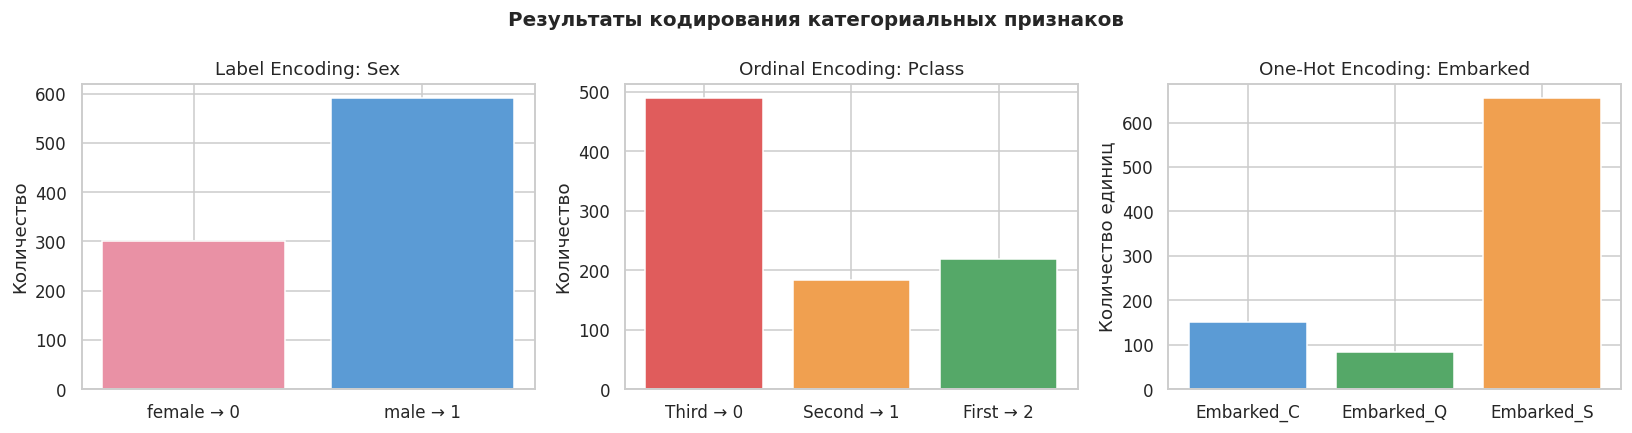

In [ ]:
# Числовые признаки для масштабирования
num_features = ['Age', 'Fare', 'SibSp', 'Parch']

print('Диапазоны числовых признаков (до масштабирования):')
print(df_clean[num_features].describe().round(3))

In [ ]:
fig, axes = plt.subplots(1, len(num_features), figsize=(14, 4))
colors = ['#5B9BD5', '#F0A050', '#55A868', '#8172B2']

for ax, col, clr in zip(axes, num_features, colors):
    data = df_clean[col].astype(float)
    ax.hist(data, bins=25, color=clr, edgecolor='white', alpha=0.85)
    ax.set_title(f'{col}\n[{data.min():.1f} – {data.max():.1f}]', fontsize=11)
    ax.set_xlabel('Значение')
    ax.set_ylabel('Частота')

plt.suptitle('Распределение признаков ДО масштабирования', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('before_scaling.png', bbox_inches='tight')
plt.show()

### 3.3 StandardScaler (Z-Score нормализация)

$$z = \frac{x - \mu}{\sigma}$$

Результат: среднее = 0, стандартное отклонение = 1. Чувствителен к выбросам.

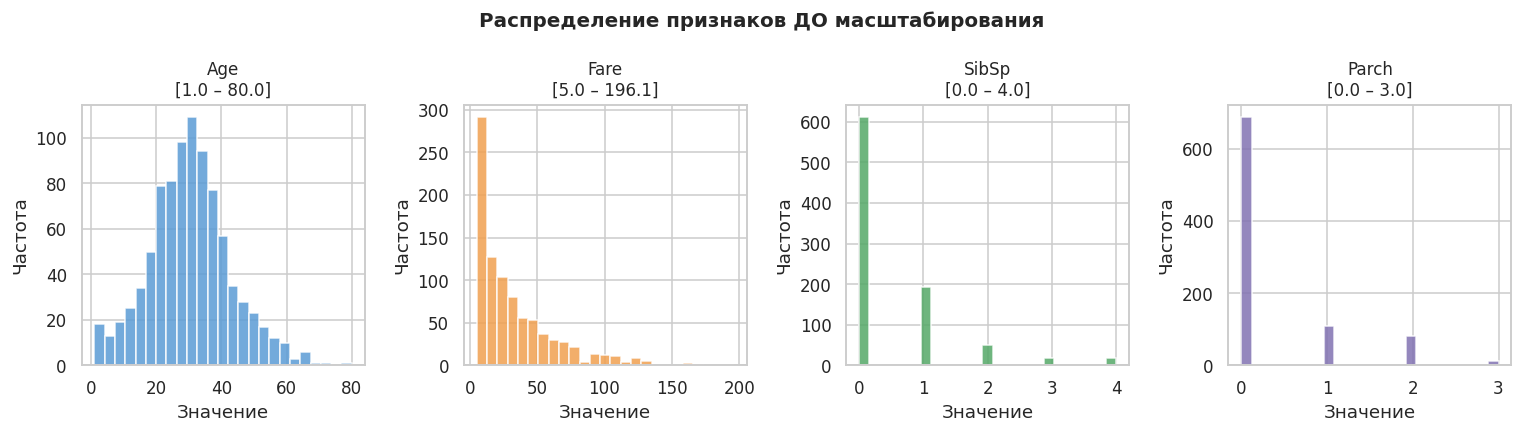

In [ ]:
X = df_clean[num_features].astype(float).values

scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)
df_std = pd.DataFrame(X_std, columns=num_features)

print('StandardScaler:')
print(f'  Средние (должны быть ~0): {df_std.mean().round(6).values}')
print(f'  Ст. откл. (должны быть ~1): {df_std.std().round(6).values}')
print()
print(df_std.describe().round(4))

### 3.4 MinMaxScaler (нормализация в диапазон [0, 1])

$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$

Результат: все значения в диапазоне [0, 1]. Сильно чувствителен к выбросам.

In [ ]:
scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X)
df_mm = pd.DataFrame(X_mm, columns=num_features)

print('MinMaxScaler:')
print(f'  Min (должны быть 0): {df_mm.min().round(6).values}')
print(f'  Max (должны быть 1): {df_mm.max().round(6).values}')
print()
print(df_mm.describe().round(4))

StandardScaler:
  Средние (должны быть ~0): [ 0.  0.  0.  0.]
  Ст. откл. (должны быть ~1): [1. 1. 1. 1.]


### 3.5 RobustScaler (устойчивый к выбросам)

$$x' = \frac{x - Q_{50}}{Q_{75} - Q_{25}}$$

Использует медиану и межквартильный размах (IQR). Наиболее устойчив к выбросам — оптимален при наличии аномальных значений (как в `Fare`).

In [ ]:
scaler_rob = RobustScaler()
X_rob = scaler_rob.fit_transform(X)
df_rob = pd.DataFrame(X_rob, columns=num_features)

print('RobustScaler:')
print(f'  Медианы (должны быть ~0): {df_rob.median().round(4).values}')
print()
print(df_rob.describe().round(4))

MinMaxScaler:
  Min (должны быть 0): [0. 0. 0. 0.]
  Max (должны быть 1): [1. 1. 1. 1.]


In [ ]:
# Визуальное сравнение трёх методов масштабирования
fig, axes = plt.subplots(4, 4, figsize=(16, 12))

datasets = [
    (df_clean[num_features].astype(float), 'Оригинал', '#AAAAAA'),
    (df_std, 'StandardScaler', '#5B9BD5'),
    (df_mm,  'MinMaxScaler',   '#F0A050'),
    (df_rob, 'RobustScaler',   '#55A868'),
]

for col_i, feat in enumerate(num_features):
    for row_i, (data, label, color) in enumerate(datasets):
        ax = axes[col_i][row_i]
        ax.hist(data[feat], bins=25, color=color, edgecolor='white', alpha=0.85)
        if col_i == 0:
            ax.set_title(label, fontsize=11, fontweight='bold')
        if row_i == 0:
            ax.set_ylabel(feat, fontsize=11, fontweight='bold')
        ax.set_xlabel('')
        mn = data[feat].mean()
        ax.axvline(mn, color='red', linestyle='--', linewidth=1.2)

plt.suptitle('Сравнение методов масштабирования по каждому признаку',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('scaling_comparison.png', bbox_inches='tight')
plt.show()

RobustScaler:
  Медианы (должны быть ~0): [0. 0. 0. 0.]


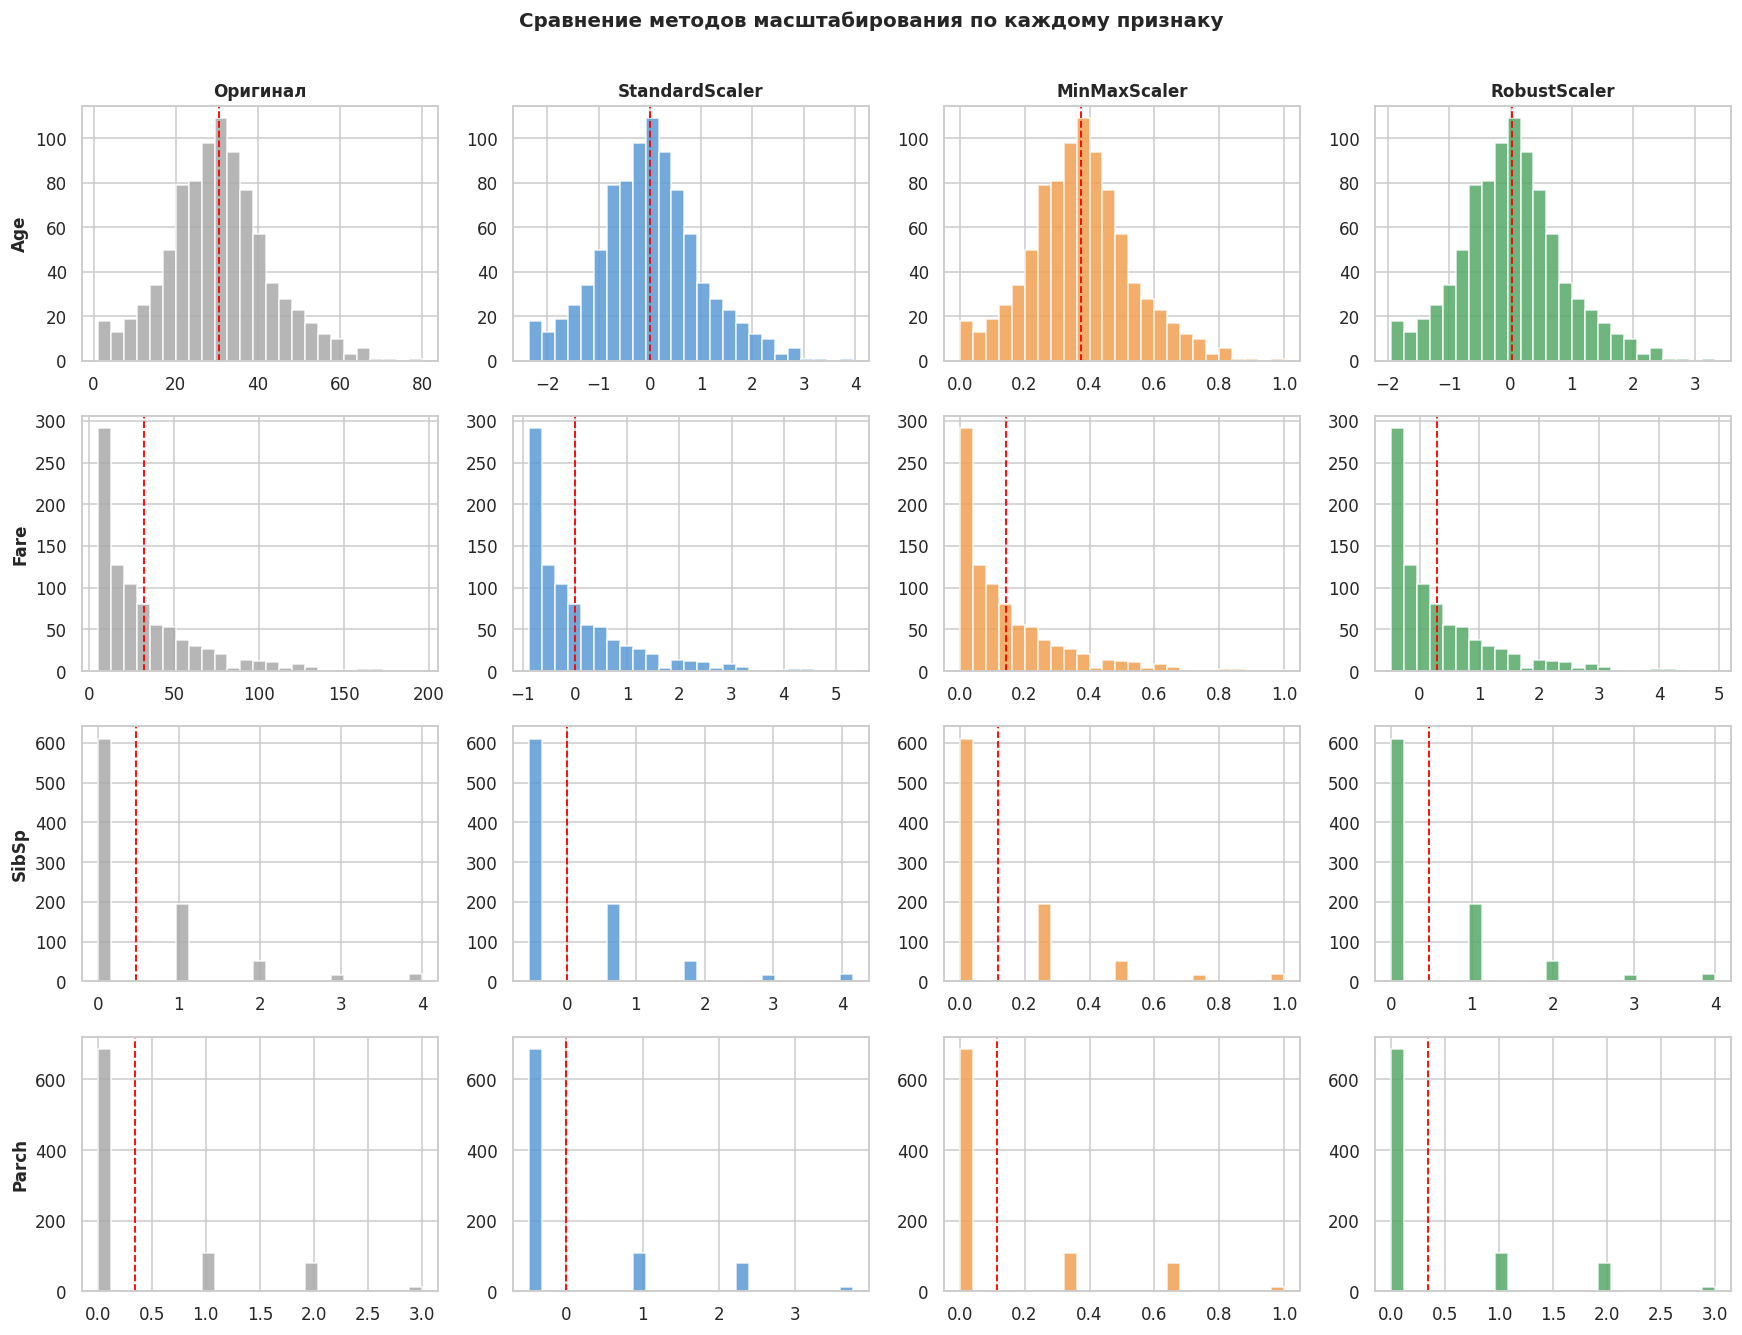

In [ ]:
# Сравнение Box Plot по всем признакам и скейлерам
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (data, label, color) in zip(axes, datasets[1:]):
    ax.boxplot([data[f] for f in num_features],
               patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_xticklabels(num_features, rotation=15)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel('Значение')
    ax.axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.7)

plt.suptitle('Box Plot после масштабирования', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scaling_boxplot.png', bbox_inches='tight')
plt.show()

---

## 4. Финальный датасет

Собираем всё вместе: после обработки пропусков, кодирования категорий и масштабирования.

In [ ]:
# Собираем финальный датасет
df_final = df_clean.copy()

# Кодирование
df_final['Sex'] = LabelEncoder().fit_transform(df_final['Sex'])        # 0/1
embarked_ohe = pd.get_dummies(df_final['Embarked'], prefix='Embarked', dtype=int, drop_first=True)
df_final = pd.concat([df_final, embarked_ohe], axis=1)
df_final.drop(columns=['Embarked'], inplace=True)

# Масштабирование числовых признаков (RobustScaler — выбор с учётом выбросов в Fare)
scaler_final = RobustScaler()
df_final[num_features] = scaler_final.fit_transform(df_final[num_features].astype(float))

# Удаляем служебный столбец
df_final.drop(columns=['PassengerId'], inplace=True)

print('Финальный датасет (первые 5 строк):')
print(df_final.head())
print(f'\nФорма: {df_final.shape}')
print(f'Пропусков: {df_final.isnull().sum().sum()}')
print(f'Типы данных:\n{df_final.dtypes}')

Финальный датасет (первые 5 строк):
   Survived  Pclass  Sex       Age      Fare  SibSp  Parch  Embarked_Q  Embarked_S
0         0       3    1  0.021732  0.031241      0      0           0           1
1         0       1    1 -0.374831  2.985201      1      0           1           0
2         1       2    0  0.314587  0.254803      0      0           0           1
3         1       3    0 -0.812143 -0.157683      0      0           0           0
4         0       3    1  0.478014 -0.214352      0      0           0           1

Форма: (891, 9)
Пропусков: 0


---

## 5. Итоги

| Задача | Метод | Признак | Результат |
|---|---|---|---|
| Обработка пропусков | Удаление признака | `Cabin` (77%) | Убран из датасета |
| Обработка пропусков | Заполнение медианой | `Fare` (0.2%) | 2 пропуска заполнены |
| Обработка пропусков | Заполнение модой | `Embarked` (0.1%) | 1 пропуск заполнен |
| Обработка пропусков | KNN-импутация (k=5) | `Age` (20%) | 187 пропусков заполнены |
| Кодирование | Label Encoding | `Sex` | 0 / 1 |
| Кодирование | One-Hot Encoding | `Embarked` | 2 новых бинарных столбца |
| Масштабирование | RobustScaler | `Age`, `Fare`, `SibSp`, `Parch` | Масштаб на основе IQR |

**Когда какой метод использовать:**

- **SimpleImputer (медиана)** — быстро, надёжно, когда пропусков мало и нет выраженной зависимости с другими признаками  
- **KNNImputer** — лучше сохраняет структуру данных, но медленнее  
- **Label Encoding** — только для бинарных или порядковых признаков  
- **One-Hot Encoding** — для номинальных признаков с небольшим числом категорий  
- **StandardScaler** — если нет выбросов, данные близки к нормальному распределению  
- **MinMaxScaler** — если нужен строго ограниченный диапазон [0, 1]  
- **RobustScaler** — при наличии выбросов (как в нашем случае с Fare)